# MoA — TabPFN (Lung_Tissue Specific Cytotoxicity Prediction)

기존 전신 세포 생존율(`c-`) 기반 독성 이진 분류 모델(`Early_Toxicity_Screening_ML_Comparison.ipynb` 등)을 **폐 조직 특화 독성 및 부작용(`Off-target`) 예측 파이프라인으로 고도화**

목적:
- **Tissue-Specific Resolution 확보**
    -> 세포 사멸을 넘어, 실제 약물이 특정 조직에서 일으킬 수 있는 부작용을 조기 예측
- **On/Off-Target 독성 분리**
    -> 항암제의 의도된 약효(`On-Target Efficacy`)와 의도치 않은 독성(`Off-Target Toxicity`)를 구분
- 그리하여, 실제 폐 기능 및 독성에 있어 **핵심적인 유전자를 선별하여 생물학적 기전으로 해석**

전처리 흐름: 
1. **폐 특화 데이터 추출** 
    : 전체 데이터셋 중에서 폐암 세포주 관련 실험 데이터 추출
    : `g-`컬럼과 실제 유전자 이름 매핑 -> `.csv`로 제작
2. **정답지 설정** 
    : `c-` 컬럼의 평균 세포 생존율을 계산하여, 특정 임계값(ex. -2.0)이하로 떨어지는 것을 독성(1) / 아닌 것을 정상(0)으로 라벨링
    : 약물 투여 농도(`cp_dose`)와 시간(`cp_time`)을 곱한 파생 변수를 생성하여 **용량-반응**에 따른 조건부 폐 독성 임계점 -> 모델에 반영
3. **Feature / Target 분리**
    : **`Target`** - 정답지 생성에 사용된 `c-` 컬럼들은 모델 입력(Feature)에서 완전히 제외(Drop)
    : **`Feature`** - 오직 `g-` 컬럼과 실험 조건(`cp_time`, `cp_dose`)만 남김.
4. **스케일링 &인코딩**
    - `cp_time`,`cp_dose` 정수 인코딩 / exposure_score 적용
    - `g-` : QuantileTransformer (train_split에 fit → val transform)
     >`QuantileTransformer` : 1등부터 순서대로 줄을 세우고, 0~1안의 수로 백분위로 표현
     >Train에만 fit하는 이유: TEST의 힌트를 얻을 수 있기에, 데이터 누수가 발생할 수 있음. 이에, Train에만 fit수행 (이후, transform하여 0~1사이 값으로 바꿈 -> Val transform)
     > Val transform: Train 데이터로 제작한 기준표를 기대로 가져와서 Test도 변경
5. **차원 축소**
    - PCA(n=500) — train_split 에 fit → 양쪽 transform
    - **`상호작용항 생성`** : 주성분 * exposure_score
6. **모델 학습**
    - 생성된 '독성(Toxicity)' 단일 이진 Target에 대해 TabPFN 학습 자료 기반 진행
    - 단일 모델(TabPFN, CatBoost, TabNet)의 비교
    - 단일 모델의 한계점을 앙상블 모델로 고도화
7. **On/Off-Target 부작용 분석**
    - 모델이 독성이라고 예측한 약물 목록을 MoA 예측 결과와 join
    - `On-Target`: 항암제로 분류된 경우
                    예) `egfr_inhibitor`, `dna_inhibitor`, `apoptosis_stimulant`
    - `Off-Target`: 항암제가 아닌 일반치료 경우

## 0. 필요한 라이브러리 설치

In [76]:
#!pip install catBoost
#!pip install pytorch-tabnet

In [113]:
import os
import time # 모델 학습 및 평가 시간 측정
import random
import warnings
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from sklearn.metrics import roc_curve, precision_recall_curve

# 모델링
from tabpfn import TabPFNClassifier
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

# 폰트
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

## 1. 경로 / 설정

In [78]:
DATA_DIR   = '../data/'
OUTPUT_DIR = 'moa_outputs_Tissue Specific Cytotoxicity Prediction'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu' # CUDA 지원 시 GPU 사용
SEED       = 42
N_SPLITS   = 5
VAL_FOLD   = 0

PCA_N_COMPONENTS = 500   # TabPFN v2 pretraining 피처 한계에 맞춤. 실험용 변수.
MAX_TARGETS      = None  # 디버그용. 전체는 None.

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"현재 사용 중인 장치: {DEVICE}")

현재 사용 중인 장치: cpu


In [79]:
#!pip install tabpfn iterative-stratification

In [80]:
# .env 파일에서 직접 읽어 환경변수에 설정
env_path = os.path.join(os.getcwd(), ".env")
if os.path.exists(env_path):
    with open(env_path) as f:
        for line in f:
            line = line.strip()
            if line.startswith("TABPFN_TOKEN="):
                token = line.split("=", 1)[1]
                os.environ["TABPFN_TOKEN"] = token
                print(f"Token loaded: {token[:20]}...")
                break
else:
    print("WARNING: .env 파일을 찾을 수 없습니다!")

TABPFN_TOKEN = os.environ.get("TABPFN_TOKEN")


Token loaded: eyJhbGciOiJIUzI1NiIs...


In [119]:
# 이미지 저장 폴더
IMAGE_DIR = os.path.join(OUTPUT_DIR, 'images')

# 폴더가 없으면 새로 만들고, 이미 있으면 에러 없이 넘어갑니다.
os.makedirs(IMAGE_DIR, exist_ok=True) 
print(f"이미지 저장 폴더 생성: {IMAGE_DIR}")

이미지 저장 폴더 생성: moa_outputs_Tissue Specific Cytotoxicity Prediction\images


## 2. 데이터 로드 (train 만)

In [81]:
random.seed(SEED); np.random.seed(SEED)

# 데이터 로드
train_features = pd.read_csv(os.path.join(DATA_DIR, "gene_name_master.csv"))

# 메타데이터 & 정답지 제작 데이터 로드
train_targets = pd.read_csv(f'{DATA_DIR}train_targets_scored.csv')
cell_info = pd.read_csv(f'{DATA_DIR}cell_info.csv')
train_drug = pd.read_csv(os.path.join(DATA_DIR, "train_drug.csv")) # GroupSplit할 때 필요!


print('train_features (Original Features) :', train_features.shape)
print('\n train_targets (Original Features) :', train_targets.shape)
print('cell_info (Original Features) :', cell_info.shape)

train_features (Original Features) : (23814, 876)

 train_targets (Original Features) : (23814, 207)
cell_info (Original Features) : (104, 2)


___
# **3. 전처리 시작**

## **1] 폐 특화 데이터 추출** 
- 전체 데이터셋 중에서 폐암 세포주 관련 실험 데이터 추출
- `g-`컬럼과 실제 유전자 이름 매핑 -> `.csv`로 제작 [`Mapping.ipynb`에서 진행!]

In [82]:
# 1. cell_info에서 폐암 세포주 실험 sig_id 추출
lung_sig_ids = cell_info[cell_info['ccle_name'].str.contains('LUNG', case=False)]['rid'].unique()
print(f"폐암 세포주 관련 sig_id 개수: {len(lung_sig_ids)}개")

# 2. train_features의 'c-컬럼' 중 폐암 세포주 rid와 일치하는 컬럼만 찾기
available_c_cols = [col for col in train_features.columns if col.startswith('c-')]
lung_c_cols = [rid for rid in lung_sig_ids if rid in available_c_cols]
print(f"실제 실험 데이터에 존재하는 폐암 세포주 관련 c-컬럼 개수: {len(lung_c_cols)}개")

# 3. 데이터 행(실험)추출
df_features = train_features.copy()  # 원본 데이터 보호를 위해 복사
df_target = train_targets.copy()      # 원본 데이터 보호를 위해 복사

print(f"\n 전체 Feature 실험 데이터 개수: {len(df_features)}건")
print(f"전체 Target 정답 데이터 수: 총 {len(df_target)}건")

폐암 세포주 관련 sig_id 개수: 15개
실제 실험 데이터에 존재하는 폐암 세포주 관련 c-컬럼 개수: 2개

 전체 Feature 실험 데이터 개수: 23814건
전체 Target 정답 데이터 수: 총 23814건


___
## **2] 정답지 설정** 
- `c-` 컬럼의 평균 세포 생존율을 계산하여, 특정 임계값(ex. -2.0)이하로 떨어지는 것을 독성(1) / 아닌 것을 정상(0)으로 라벨링
- 약물 투여 농도(`cp_dose`)와 시간(`cp_time`)을 곱한 파생 변수를 생성하여 **용량-반응**에 따른 조건부 폐 독성 임계점 -> 모델에 반영

In [83]:
# 4. 정답 데이터 (폐암 C-컬럼의 세포 생존율 평균만 계산)
df_features['lung_c_mean'] = df_features[lung_c_cols].mean(axis=1)
print(f"폐암 세포주 관련 c-컬럼 평균값이 추가된 Feature 데이터 개수: {len(df_features)}건")

# 폐암 세포 생존율이 평균 -2.0이하 : 독성(1)로 라벨링
df_features['toxicity'] = (df_features['lung_c_mean'] <= -2.0).astype(int)
print(f"\n 폐 특화 독성 라벨링 sample 수: {df_features['toxicity'].sum()}건")


# 5. 용량-반응에 따른 파생변수 생성 [노출지수]

df_features['cp_time_enc'] = df_features['cp_time'].map({24: 0, 48: 1, 72: 2})
df_features['cp_dose_enc'] = df_features['cp_dose'].map({'D1': 0, 'D2': 1})

# weight(1,2,3)
time_weight = df_features['cp_time'].map({24: 1, 48: 2, 72: 3})
dose_weight = df_features['cp_dose'].map({'D1': 1, 'D2': 2})

# 최종 노출 지수 생성 (1 ~ 6)
df_features['exposure_score'] = time_weight * dose_weight

폐암 세포주 관련 c-컬럼 평균값이 추가된 Feature 데이터 개수: 23814건

 폐 특화 독성 라벨링 sample 수: 1763건


___
## **3] Feature / Target 분리 (데이터 누수 방지)**
- **`Target`** - 정답지 생성에 사용된 `c-` 컬럼들은 모델 입력(Feature)에서 완전히 제외(Drop)

    : **`Feature`** - 오직 `g-` 컬럼과 실험 조건(`cp_time`, `cp_dose`)만 남김.

In [84]:
# 모델이 학습할 문제(X)와 정답(y) 나누기
# 정답지 분리하기
y_data = df_features[['sig_id','toxicity']].copy()

# 문제지
cols_to_drop = lung_c_cols + ['lung_c_mean', 'cp_type', 'cp_dose','cp_time', 'sig_id', 'toxicity']
x_data = df_features.drop(columns=cols_to_drop).copy()

# 유전자 필터링
other_cols = ['cp_time_enc', 'cp_dose_enc', 'exposure_score']
g_cols = [col for col in x_data.columns if col not in other_cols]

# 학습 및 검증을 위해 drug_id 결합 (sig_id가 남아있는 df_features 기준으로 merge)
df_merged = pd.merge(df_features[['sig_id']], train_drug[['sig_id', 'drug_id']], on='sig_id', how='left')

print("Feature, Target 분리 완료")
print(f"\n문제지 크기: {x_data.shape}")
print(f"정답지 크기: {y_data.shape}")

Feature, Target 분리 완료

문제지 크기: (23814, 873)
정답지 크기: (23814, 2)


___
## **4] 스케일링 및 인코딩**
- `cp_time`,`cp_dose` 정수 인코딩 / exposure_score 적용
- `g-` : QuantileTransformer (train_split에 fit → val transform)

___
### **Train과 Test 데이터 나누기**
___

In [85]:
# Train, Test 데이터 생성
 # stratify=y 를 통해 '독성 물질(Label=1)'이 양쪽 그룹에 골고루 분포하도록 나눔

# 같은 drug_id 가진 데이터 함께 묶어 분할 수행
drug_s = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(drug_s.split(x_data, y_data['toxicity'], groups=df_merged['drug_id']))

print("Train, Test 데이터 나누기")
X_train, X_val= x_data.iloc[train_idx].copy(), x_data.iloc[val_idx].copy()
y_train, y_val = y_data['toxicity'].iloc[train_idx].copy(), y_data['toxicity'].iloc[val_idx].copy()
val_sig_ids = y_data['sig_id'].iloc[val_idx].values # On/Off target용

print("\nTrain, Test 데이터 나누기 완료")
print(f"학습 데이터 크기: {X_train.shape}, 검증용 데이터 크기: {X_val.shape}")

Train, Test 데이터 나누기

Train, Test 데이터 나누기 완료
학습 데이터 크기: (19736, 873), 검증용 데이터 크기: (4078, 873)


___
### **스케일링**

- 유전자와 실험 조건 데이터는 성격이 다르므로, 스케일링 및 PCA 차원 축소단계에서 다르게 다룸
___

In [86]:
# 스케일링 (QuantileTransformer)
qt = QuantileTransformer(output_distribution='normal', random_state=SEED)
X_train[g_cols] = qt.fit_transform(X_train[g_cols])
X_val[g_cols] = qt.transform(X_val[g_cols])

# Numpy 배열로 변환
 # 메모리의 사용량을 절반으로 줄임으로 모델이 빠르게 학습할 수 있도록 함
X_train_raw = X_train.astype(np.float32).values
y_train     = y_train.values.astype(np.float32)
X_val_raw = X_val.astype(np.float32).values
y_val     = y_val.values.astype(np.float32)

print("스케일링 완료")
print('X_train_raw:', X_train_raw.shape, ' Y_train:', y_train.shape)
print('X_val_raw  :', X_val_raw.shape,   ' Y_val  :', y_val.shape)


스케일링 완료
X_train_raw: (19736, 873)  Y_train: (19736,)
X_val_raw  : (4078, 873)  Y_val  : (4078,)


___
## **5] 차원 축소**
- PCA(n=500) — train_split 에 fit → 양쪽 transform
- **`상호작용항 생성`** : 주성분 * exposure_score

In [87]:
# PCA 설정
n_comp = min(PCA_N_COMPONENTS, X_train_raw.shape[1], X_train_raw.shape[0])
pca = PCA(n_components=n_comp, random_state=SEED)
pca.fit(X_train_raw)

X_train_g = pca.fit_transform(X_train[g_cols]).astype(np.float32)
X_val_g   = pca.transform(X_val[g_cols]).astype(np.float32)

print(f'PCA n_components={n_comp}  explained_variance_ratio sum={pca.explained_variance_ratio_.sum():.4f}')
print('X_train_g:', X_train_g.shape, ' X_val_g:', X_val_g.shape)


# 상호직용하는 항 생성 
def create_interaction_terms(X_df, X_pca, n_interact=5):
    # 노출 지수를 가져옴
    exposure = X_df['exposure_score'].values.reshape(-1, 1)
    # PCA 상위 n_interact 개 특성과 노출 지수를 곱함
    interaction = X_pca[:, :n_interact] * exposure
    return interaction

train_interact = create_interaction_terms(X_train, X_train_g)
val_interact   = create_interaction_terms(X_val, X_val_g)

# 다른 변수(cp_time_enc, cp_dose_enc) + pca 유전자 +상호작용
X_train_final = np.hstack([X_train[other_cols].values, X_train_g, train_interact])
X_val_final   = np.hstack([X_val[other_cols].values, X_val_g, val_interact])

print("\n최종 데이터셋 준비 완료")
print(f"X_train_final: {X_train_final.shape}")
print(f"X_val_final  : {X_val_final.shape}")

PCA n_components=500  explained_variance_ratio sum=0.8910
X_train_g: (19736, 500)  X_val_g: (4078, 500)

최종 데이터셋 준비 완료
X_train_final: (19736, 508)
X_val_final  : (4078, 508)


___
## **6] 모델 학습**
- 생성된 '독성(Toxicity)' 단일 이진 Target에 대해 TabPFN 학습 자료 기반 진행
- 단일 모델(TabPFN, CatBoost, TabNet)의 비교
- 단일 모델의 한계점을 앙상블 모델로 고도화

In [ ]:
# ==========================================
# 데이터 500개 샘플링
#SAMPLE_SIZE = 500
#X_train_final = X_train_final[:SAMPLE_SIZE]
#y_train = y_train[:SAMPLE_SIZE]
#X_val_final = X_val_final[:SAMPLE_SIZE]
#y_val = y_val[:SAMPLE_SIZE]
#X_val = X_val[:SAMPLE_SIZE] 
#print(f"테스트용 데이터 세팅 완료! Train: {X_train_final.shape}, Val: {X_val_final.shape}")

테스트용 데이터 세팅 완료! Train: (500, 508), Val: (500, 508)


___
### **단일 모델(TabPFN / CatBoost / TabNet)**
___

In [89]:
# 1. 모델 구축
 # TabPFN
def model_TabPFN():
    return TabPFNClassifier(
        device=DEVICE,
        random_state=SEED,
        ignore_pretraining_limits=True
    )
 # CatBoost
def model_CatBoost():
    return CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric='AUC',
        random_seed=SEED,
        verbose=100
    )
 # TabNet
def model_TabNet():
    return TabNetClassifier(
        n_d=64, n_a=64, n_steps=5,
        gamma=1.5, n_independent=2, n_shared=2,
        lambda_sparse=1e-3,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type='entmax',
        device_name=DEVICE
    )
# 실행할 모델 리스트
model_to_run = {
    'TabPFN': model_TabPFN,
    'CatBoost': model_CatBoost,
    'TabNet': model_TabNet
}

In [91]:
# 모델 학습 및 평가
model_probs = {}  # 모델별 예측 확률 저장용
results = {}      # 모델별 평가 지표 저장용

for name, model_fn in model_to_run.items():
    print(f"=== {name} 모델 학습 시작 ===")
    model = model_fn()

    start_time = time.time()
    if name == 'TabPFN':
        model.fit(X_train_final, y_train.astype(int))
    elif name == 'CatBoost':
        model.fit(
            X_train_final, y_train.astype(int),
            eval_set=(X_val_final, y_val.astype(int)),
            early_stopping_rounds=50
        )
    elif name == 'TabNet':
        model.fit(
            X_train_final, y_train.astype(int),
            eval_set=[(X_val_final, y_val.astype(int))],
            eval_metric=['auc'],
            patience=50,
            max_epochs=200,
            batch_size=256
        )
    elapsed_time = time.time() - start_time
    print(f"{name} 학습 완료 (소요 시간: {elapsed_time:.2f}초)")

    probs = model.predict_proba(X_val_final)[:, 1]
    model_probs[name] = probs

    auc = roc_auc_score(y_val, probs)
    ap  = average_precision_score(y_val, probs)
    ll  = log_loss(y_val, probs)

    results[name] = {'AUC': auc, 'AP': ap, 'LogLoss': ll, 'Time(s)': round(elapsed_time, 2)}
    print(f"{name} 평가 결과: AUC={auc:.4f}, AP={ap:.4f}, LogLoss={ll:.4f}")


=== TabPFN 모델 학습 시작 ===
TabPFN 학습 완료 (소요 시간: 9.95초)
TabPFN 평가 결과: AUC=0.9908, AP=0.8552, LogLoss=0.0587
=== CatBoost 모델 학습 시작 ===
0:	test: 0.9786932	best: 0.9786932 (0)	total: 629ms	remaining: 10m 28s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9985795455
bestIteration = 4

Shrink model to first 5 iterations.
CatBoost 학습 완료 (소요 시간: 10.15초)
CatBoost 평가 결과: AUC=0.9986, AP=0.9673, LogLoss=0.3281
=== TabNet 모델 학습 시작 ===
epoch 0  | loss: 0.89565 | val_0_auc: 0.3976  |  0:00:01s
epoch 1  | loss: 0.53978 | val_0_auc: 0.48179 |  0:00:02s
epoch 2  | loss: 0.41837 | val_0_auc: 0.4632  |  0:00:03s
epoch 3  | loss: 0.47747 | val_0_auc: 0.52027 |  0:00:04s
epoch 4  | loss: 0.4023  | val_0_auc: 0.54649 |  0:00:05s
epoch 5  | loss: 0.46461 | val_0_auc: 0.50594 |  0:00:06s
epoch 6  | loss: 0.42561 | val_0_auc: 0.58665 |  0:00:07s
epoch 7  | loss: 0.37349 | val_0_auc: 0.4876  |  0:00:07s
epoch 8  | loss: 0.36655 | val_0_auc: 0.60034 |  0:00:08s
epoch 9  | loss: 0.26296 | val_0_a

In [93]:
# 각 모델 결과 csv 저장
for name, probs in model_probs.items():
    current_length = len(probs)
    sliced_val_sig_ids = val_sig_ids[:current_length]

    df_out = pd.DataFrame({
        'sig_id': sliced_val_sig_ids,
        'y_true': y_val.astype(int),
        f'prob_{name}': probs
    })
    save_path = os.path.join(OUTPUT_DIR, f'val_pred_{name}.csv')
    df_out.to_csv(save_path, index=False)
    print(f"저장 완료: {save_path}")


저장 완료: moa_outputs_Tissue Specific Cytotoxicity Prediction\val_pred_TabPFN.csv
저장 완료: moa_outputs_Tissue Specific Cytotoxicity Prediction\val_pred_CatBoost.csv
저장 완료: moa_outputs_Tissue Specific Cytotoxicity Prediction\val_pred_TabNet.csv


___
### **앙상블 모델**
___

In [94]:
# Soft Voting 앙상블: 세 모델 예측 확률 평균
ensemble_prob = np.mean(list(model_probs.values()), axis=0)
model_probs['Ensemble'] = ensemble_prob

auc_ens = roc_auc_score(y_val, ensemble_prob)
ap_ens  = average_precision_score(y_val, ensemble_prob)
ll_ens  = log_loss(y_val, ensemble_prob)

results['Ensemble'] = {'AUC': auc_ens, 'AP': ap_ens, 'LogLoss': ll_ens, 'Time(s)': '-'}
print(f"Ensemble (Soft Voting)  AUC={auc_ens:.4f}, AP={ap_ens:.4f}, LogLoss={ll_ens:.4f}")


Ensemble (Soft Voting)  AUC=0.9959, AP=0.9388, LogLoss=0.1232


## **4. Val 예측 저장**

In [96]:
# 모델별 평가 결과 출력
pred_matrix = np.column_stack(list(model_probs.values()))
target_cols = list(model_probs.keys())
current_length = pred_matrix.shape[0]
valid_sig_ids = val_sig_ids[:current_length]

# 모델별 예측 확률을 DataFrame으로 변환
val_pred_df = pd.DataFrame(pred_matrix, columns=target_cols)
val_pred_df.insert(0, 'sig_id', valid_sig_ids)
pred_path = f'{OUTPUT_DIR}/val_pred_tabpfn_Cytotoxicity_prediction_split_pca{n_comp}.csv'
val_pred_df.to_csv(pred_path, index=False)
print('wrote', pred_path)
val_pred_df.head()

wrote moa_outputs_Tissue Specific Cytotoxicity Prediction/val_pred_tabpfn_Cytotoxicity_prediction_split_pca500.csv


,sig_id,TabPFN,CatBoost,TabNet,Ensemble
0,id_003603254,0.000371,0.306618,4.176980e-01,0.241562
1,id_0039a2ff9,0.000010,0.260149,3.827047e-07,0.086720
2,id_003b43239,0.000010,0.258626,1.491209e-06,0.086212
3,id_003fdd734,0.000023,0.247048,8.261343e-05,0.082384
4,id_00548fd5c,0.000010,0.287804,1.700830e-08,0.095938


## **5. 평가 : mean column-wise log-loss**

In [102]:
# 1. 정답지 모양 맞추기 (1차원 -> 2차원으로 변경)
if hasattr(y_val, 'values'):
    y_true_arr = y_val.values.astype(np.float32).reshape(-1, 1)
else:
    y_true_arr = y_val.astype(np.float32).reshape(-1, 1)

# 2. 예측 확률 2차원 + 극단적인 값 잘라내기.
y_pred_arr = np.clip(pred_matrix.astype(np.float32), 1e-15, 1 - 1e-15)

# 브로드캐스팅 에러 방지
log_loss_matrix = -(y_true_arr * np.log(y_pred_arr) + (1 - y_true_arr) * np.log(1 - y_pred_arr))
loss = log_loss_matrix.mean()
print(f'Mean column-wise log-loss (TabPFN drug_id split + PCA{n_comp}, fold={VAL_FOLD}): {loss:.5f}')

Mean column-wise log-loss (TabPFN drug_id split + PCA500, fold=0): nan


___
## **6. On/Off-Target 부작용 분석**

- 모델이 독성이라고 예측한 약물 목록을 MoA 예측 결과와 join
- `On-Target`: 항암제로 분류된 경우
___

In [104]:
# On-Target MoA 정의 (폐암 치료에 직접 관련된 항암 기전)
ON_TARGET_MOAS = [
    'egfr_inhibitor',           # 폐암 1차 표적 치료제 (EGFR 돌연변이)
    'alk_inhibitor',            # 폐암 표적 치료제 (ALK 재배열)
    'dna_inhibitor',            # 항암 화학요법
    'dna_alkylating_agent',     # 항암 화학요법 (시스플라틴 계열)
    'topoisomerase_inhibitor',  # 항암 화학요법 (에토포시드 계열)
    'tubulin_inhibitor',        # 항암 화학요법 (탁산, 빈카 알칼로이드)
    'apoptosis_stimulant',      # 세포 사멸 유도
    'cdk_inhibitor',            # 세포 주기 억제
    'mek_inhibitor',            # KRAS 돌연변이 폐암 치료
    'vegfr_inhibitor',          # 항혈관신생 치료
    'tyrosine_kinase_inhibitor',
    'protein_tyrosine_kinase_inhibitor',
]

In [107]:
# 샘플링 길이
current_length = len(model_probs['Ensemble']) # 현재 500개
valid_sig_ids = val_sig_ids[:current_length]
valid_y_val = y_val.values[:current_length] if hasattr(y_val, 'values') else y_val[:current_length]

# 1. Ensemble 예측 기준 독성 샘플 sig_id 추출
THRESHOLD = 0.5
pred_toxic_mask = model_probs['Ensemble'] > THRESHOLD
pred_toxic_sig_ids = valid_sig_ids[pred_toxic_mask]

print(f'검증셋 전체: {len(valid_sig_ids)}개')
print(f'독성 예측 샘플 (prob > {THRESHOLD}): {pred_toxic_mask.sum()}개')
print(f'실제 독성(y=1) 중 맞춤: {int(valid_y_val[pred_toxic_mask].sum())}개')

# 2. MoA 라벨과 Join
moa_toxic = train_targets[train_targets['sig_id'].isin(pred_toxic_sig_ids)].copy()

prob_df_val = pd.DataFrame({
    'sig_id': valid_sig_ids,
    'y_true': valid_y_val.astype(int),
    'ensemble_prob': model_probs['Ensemble']
})
moa_toxic = moa_toxic.merge(prob_df_val, on='sig_id', how='left')

# 3. On/Off-Target 분류
available_on_target = [c for c in ON_TARGET_MOAS if c in moa_toxic.columns]
moa_toxic['is_on_target'] = moa_toxic[available_on_target].sum(axis=1) > 0
moa_toxic['target_type']  = moa_toxic['is_on_target'].map({True: 'On-Target', False: 'Off-Target'})

print('\n=== On/Off-Target 분류 결과 ===')
print(moa_toxic['target_type'].value_counts().to_string())

검증셋 전체: 500개
독성 예측 샘플 (prob > 0.5): 11개
실제 독성(y=1) 중 맞춤: 11개

=== On/Off-Target 분류 결과 ===
target_type
Off-Target    6
On-Target     5


In [108]:
# 4. 결과 저장
save_cols = ['sig_id', 'y_true', 'ensemble_prob', 'target_type'] + available_on_target
moa_toxic[save_cols].to_csv(f'{OUTPUT_DIR}/on_off_target_analysis.csv', index=False)
print(f'저장 완료: {OUTPUT_DIR}/on_off_target_analysis.csv')

# 5. Off-Target 샘플에서 가장 많은 MoA 확인
all_moa_cols = [c for c in moa_toxic.columns
                if c not in ['sig_id','y_true','ensemble_prob','is_on_target','target_type']]
off_target_df = moa_toxic[moa_toxic['target_type'] == 'Off-Target']
if len(off_target_df) > 0:
    off_moa_counts = off_target_df[all_moa_cols].sum().sort_values(ascending=False)
    print('\n=== Off-Target 독성 샘플의 주요 MoA (상위 10개) ===')
    print(off_moa_counts[off_moa_counts > 0].head(10).to_string())

저장 완료: moa_outputs_Tissue Specific Cytotoxicity Prediction/on_off_target_analysis.csv

=== Off-Target 독성 샘플의 주요 MoA (상위 10개) ===
hsp_inhibitor               2
chk_inhibitor               1
rna_polymerase_inhibitor    1


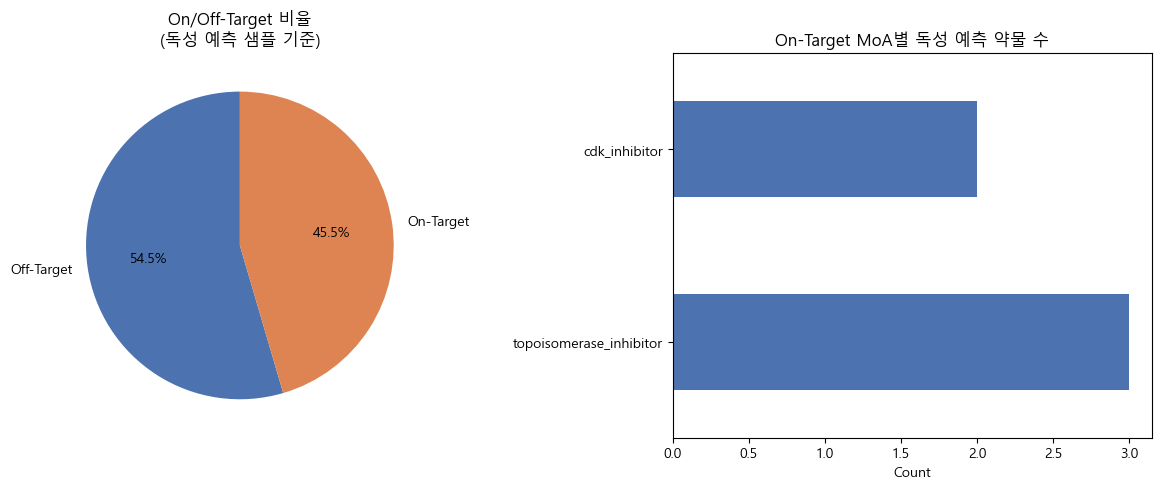

이미지 저장 완료: moa_outputs_Tissue Specific Cytotoxicity Prediction\images\on_off_target_analysis.png


<Figure size 640x480 with 0 Axes>

In [120]:
# 시각화: On vs Off-Target 비율 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = moa_toxic['target_type'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0].set_title('On/Off-Target 비율\n(독성 예측 샘플 기준)')

on_target_df = moa_toxic[moa_toxic['target_type'] == 'On-Target']
if len(on_target_df) > 0:
    on_moa_counts = on_target_df[available_on_target].sum().sort_values(ascending=False)
    on_moa_counts[on_moa_counts > 0].plot(kind='barh', ax=axes[1], color='#4C72B0')
    axes[1].set_title('On-Target MoA별 독성 예측 약물 수')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'On-Target 샘플 없음', ha='center', va='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/on_off_target_analysis.png', dpi=150)
plt.show()

# 이미지 저장
on_off_image_path = os.path.join(IMAGE_DIR, 'on_off_target_analysis.png')
plt.savefig(on_off_image_path, dpi=150)
print(f"이미지 저장 완료: {on_off_image_path}")

___
## **7. 모델 비교 시각화**
- ROC Curve / PR Curve / Correlation Heatmap / 수치형 요약 리포트

___
#### **ROC Curve**
___

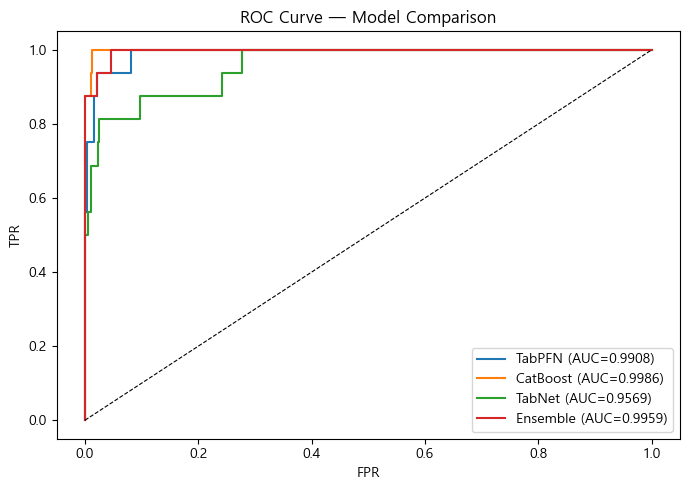

이미지 저장 완료: moa_outputs_Tissue Specific Cytotoxicity Prediction\images\roc_curve_comparison.png


<Figure size 640x480 with 0 Axes>

In [121]:
plt.figure(figsize=(7, 5))
for name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_val.astype(int), probs)
    auc = results[name]['AUC']
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve — Model Comparison')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curve_comparison.png', dpi=150)
plt.show()

# 이미지 저장
roc_image_path = os.path.join(IMAGE_DIR, 'roc_curve_comparison.png')
plt.savefig(roc_image_path, dpi=150)
print(f"이미지 저장 완료: {roc_image_path}")

___
#### **PR Curve**
___

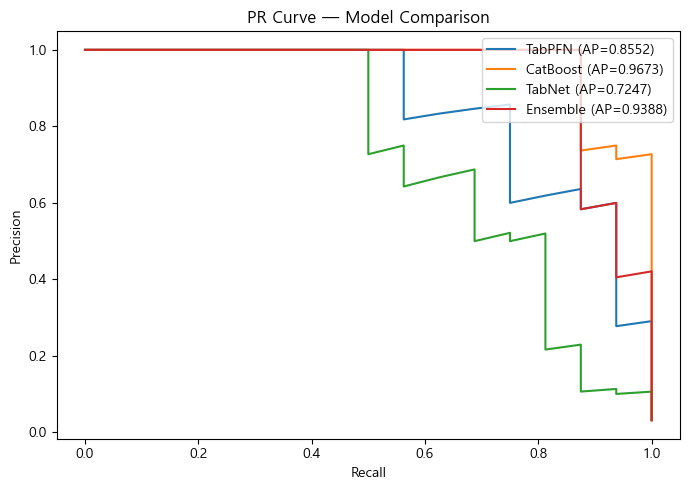

In [ ]:
plt.figure(figsize=(7, 5))
for name, probs in model_probs.items():
    prec, rec, _ = precision_recall_curve(y_val.astype(int), probs)
    ap = results[name]['AP']
    plt.plot(rec, prec, label=f"{name} (AP={ap:.4f})")

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('PR Curve — Model Comparison')
plt.legend(loc='upper right'); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pr_curve_comparison.png', dpi=150)
plt.show()

# 이미지 저장
pr_image_path = os.path.join(IMAGE_DIR, 'pr_curve_comparison.png')
plt.savefig(pr_image_path, dpi=150)
print(f"이미지 저장 완료: {pr_image_path}")


___
#### **Correlation Heatmap**
___

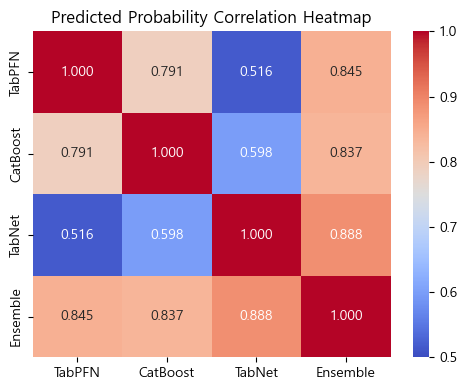

이미지 저장 완료: moa_outputs_Tissue Specific Cytotoxicity Prediction\images\correlation_heatmap.png


<Figure size 640x480 with 0 Axes>

In [122]:
prob_df = pd.DataFrame({name: probs for name, probs in model_probs.items()})
corr = prob_df.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=0.5, vmax=1.0)
plt.title('Predicted Probability Correlation Heatmap')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlation_heatmap.png', dpi=150)
plt.show()

# 이미지 저장
corr_image_path = os.path.join(IMAGE_DIR, 'correlation_heatmap.png')
plt.savefig(corr_image_path, dpi=150)
print(f"이미지 저장 완료: {corr_image_path}")

___
#### **수치형 요약 리포트**
___

In [118]:
summary_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
summary_df = summary_df.sort_values('AUC', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))
summary_df.to_csv(f'{OUTPUT_DIR}/model_comparison_summary.csv', index=False)

   Model       AUC        AP   LogLoss Time(s)
CatBoost   0.99858   0.96733  0.328149   10.15
Ensemble  0.995868  0.938816  0.123198       -
  TabPFN  0.990832  0.855184  0.058726    9.95
  TabNet   0.95687  0.724732   0.08912   77.08
